# Updating Probabilities

---

## Outline

* [Decisions](#Decisions)
* [Conditional Probability](#Conditional-Probability)
* [Tree Diagrams](#Tree-Diagrams)
* [Bayes' Rule](#Bayes'-Rule)
* [Subjective Probabilities](#Subjective-Probabilities)

---

## Set Up the Notebook

In [1]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

---

## Decisions Under Uncertainty

---

In [2]:
year = np.array(['Second']*60 + ['Third']*40)
major = np.array(['Undeclared']*30+['Declared']*30+['Undeclared']*8+['Declared']*32)
students = Table().with_columns(
    'Year', year,
    'Major', major
)

In [ ]:
students.show(3)

In [ ]:
students.pivot('Major', 'Year')

In [ ]:
32/(30+32)

In [3]:
students.pivot('Major', 'Year')

Year,Declared,Undeclared
Second,30,30
Third,32,8


### Scenario: Medical Testing

[*Interpretation by Physicians of Clinical Laboratory Results (1978)*](https://www.nejm.org/doi/full/10.1056/nejm197811022991808)

> We asked 20 house officers, 20 fourth-year medical students and 20 attending physicians, selected in 67 consecutive hallway encounters at four Harvard Medical School teaching hospitals, the following question:
>
> _If a test to detect a disease whose prevalence is 1/1000 has a false positive rate of 5%, what is the chance that a person found to have a positive result actually has the disease, assuming that you know nothing about the person's symptoms or signs?_
>
> Eleven of 60 participants, or 18%, gave the correct answer. These participants included four of 20 fourth-year students, three of 20 residents in internal medicine and four of 20 attending physicians. The most common answer, given by 27, was that \[the chance that a person found to have a positive result actually has the disease\] was 95%.

* Rare disease with prevalence of 1/1000 in population
* There is a test (e.g., antigen test) with the following properties
    * False Positive Rate of 5%: If you do NOT have the disease then 5% of the time, the test says you do.
    * False Negative Rate of 1%: If you DO have the disease then 1% of the time, the test says you do not have the disease.
* If you sample a person at random and they test positive, what is the chance they have the rare disease?

---

### Truth and Test Results

All patients fall into one of 4 categories:

<img src="./truth_and_test_results.png" alt="Table showing the 4 possible outcomes for the patient." width=70%>

---

### False Positive Rate

<img src="./false_positive_rate.png" alt="Same table focusing on the first row as if they test indicated positive."  width=70%>

---

### False Negative Rate

<img src="./false_negative_rate.png" alt="Same table focusing on the first row as if they test indicated negative."  width=70%>

---

## Unconditional and Conditional Probabilities

---

### Scenario: Education

#### Background

* Class consists of Freshmen (60%) and Sophomores (40%)
* Some of the students have declared their major
    * 50% of the Freshmen have declared their major
    * 80% of the Sophomores have declared their major

#### Unconditional Probability

* If I pick one student at random ... 
* What is the chance they are a Sophomore?
    * **Unconditional probability** of being a sophomore
    * No additional information is given
    * The probability that the student is a sophomore is 40%.

#### Conditional Probability

* If I pick one **Sophomore** student at random ...
* **Given Information: That student is a sophomore!**
* What is the chance that they have declared a major?
    * **Conditional probability** of declaring a major, given that the student is a Sophomore.
    * The probability that the student (who is a Sophomore) has declared a major is 80%.


#### Another Conditional Probability

* If I pick one student who **declared a major** at random...
* **Given Information: That student has declared a major!**
* What is the chance they are a Sophomore?
    * **Conditional probability** of being a sophomore, given that the student has declared a major.
    * The probability that the student (who declared a major) is a sophomore is ... ???

---

## Conditional Probability

---

### What do these scenarios have in common?

* There is some chance event that I am interested in 
    * person has a disease
    * the student's year
* I start with some prior (before observing anything) information about that quantity:
    * P(Disease)
    * P(Year)
* I then observe something whose value depends probabilistically on the original chance event:
    * Test is Positive
    * Student has declared
    * Neither piece of information exactly determines the original event
* How do I update the probability of the original event given the additional information?

---

### Conditional Probability

* Probability of an event given some information (it is conditioned on the information)
* Example: 
    * “80% of Sophomores are Declared” 
    * P(Declared | Sophomore) = 0.8 ← Notation

---

### Conditional vs Joint Probabilities 

* The **joint probability** of two events: 
    * P(Declared, Sophomore) = chance of a random student being a declared and a Sophomore
* The **conditional probability** (the stuff after | is given):
    * P(Declared | Sophomore) = chance of a random Sophomore student being declared 
* Which one is bigger? Let's see.

---

### Example: Comparing Conditional and Joint Probabilities

In [4]:
from IPython.display import IFrame
IFrame('https://docs.google.com/presentation/d/e/2PACX-1vRiLsFDsuuT\
_fGEkjNJJ5Yv6MdEkWshYniIDyrzR4F4vN7UkAUgwT-MrhUTy8_gxwyhLv3rTleNScXw\
/embed?start=false&loop=false&delayms=3000', 960, 569)

---

## Tree Diagrams

---

### Tree Diagrams

In [5]:
from IPython.display import IFrame
IFrame('https://docs.google.com/presentation/d/e/2PACX-1vTYqt2\
-0qckaBNAHfug29S4o0IV-tCrPkOp3a01wWsx65iyAmpFX3gI9ROkaZ21Syf77\
xyiIIDrGAgS/embed?start=false&loop=false&delayms=3000', 960, 569)

---

## Bayes' Rule

---

### Bayes' Rule

In [6]:
from IPython.display import IFrame
IFrame('https://docs.google.com/presentation/d/e/2PACX-1vSTI_AHfonqA-\
ww_uTioJOpF_sy8PHvEkaZ1B0ahy-KdKXygejBtQeQpIACZ0xNLnEYCfTbfkSC3Klw/\
embed?start=false&loop=false&delayms=3000', 960, 569)

---

### A Closer Look at the Answer

Assume a patient is picked at random.
* Prior probability of disease 
    * P(Disease) = 0.001 = one-tenth of 1%
* Posterior probability of disease given positive test
    * P(Disease | Test positive) = 0.0194... ≅ 2%
* Bigger than the prior, but still pretty small
* Should we approve such a test?
    * The test has low error rates compared to most tests
* How can this be?


---

### Assumptions Matter

* "Assume a patient is picked at random."
    * But usually, people aren’t picked at random for medical tests
    * So our intuition about randomly picked patients may not be great
* For a randomly picked patient, the result does make sense, because the disease is very rare.
* What if the doctor believes there is a 10% chance the patient has the disease?

---

### Bayes' Rule and Covid Testing

<a href="https://www.theguardian.com/world/2021/apr/18/obscure-maths-bayes-theorem-reliability-covid-lateral-flow-tests-probability" title="The obscure maths theorem that governs the reliability of Covid testing - The Guardian"><img src="./bayes.png" width=50%></a>

> "Without knowing the prior probability, you don't know how likely it is that a result is false or true."

> The government says – accurately – that the “false positive rate”, the chance of a test returning a positive result in a person who does not have the disease, is less than one in 1,000. And that’s where we came in: you might think that that means, if you’ve had a positive result, that there’s a less than one in 1,000 chance that it’s false.

---

### Demo: Bayes' Rule

* Create a function that calculates $P(A \mid B) = \frac{P(A) \cdot P(B\mid A)}{P(B)}$
* Use `bayes_rule` to calculate the probability for the original medical question.
* How does the conditional probability change when the prior is larger?
* Notice how quickly the Posterior probability climbs as the Prior probability increases.

Many medical tests for diseases return Positive or Negative results. A Positive result means that according to the test, the patient has the disease. A Negative result means the test concludes that the patient doesn't have the disease.

Medical tests are carefully designed to be very accurate. But few tests are accurate 100% of the time. Almost all tests make errors of two kinds:

A false positive is an error in which the test concludes Positive but the patient doesn't have the disease.

A false negative is an error in which the test concludes Negative but the patient does have the disease.

These errors can affect people's decisions. False positives can cause anxiety and unnecessary treatment (which in some cases is expensive or dangerous). False negatives can have even more serious consequences if the patient doesn't receive treatment because of their Negative test result.

A Test for a Rare Disease
Suppose there is a large population and a disease that strikes a tiny proportion of the population. The tree diagram below summarizes information about such a disease and about a medical test for it

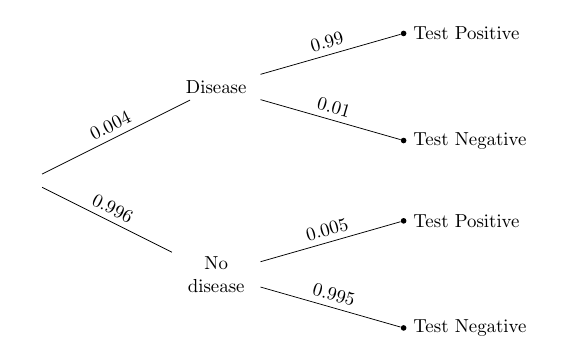

Overall, only 4 in 1000 of the population has the disease. The test is quite accurate: it has a very small false positive rate of 5 in 1000, and a somewhat larger (though still small) false negative rate of 1 in 100.

Individuals might or might not know whether they have the disease; typically, people get tested to find out whether they have it.

So suppose a person is picked at random from the population and tested. If the test result is Positive, how would you classify them: Disease, or No disease?

We can answer this by applying Bayes' Rule and using our "more likely than not" classifier. Given that the person has tested Positive, the chance that he or she has the disease is the proportion in the top branch, relative to the total proportion in the Test Positive branches.

In [7]:
def population(prior_prob_disease):
    n_d = int(prior_prob_disease*100000)
    n_nd = 100000 - n_d
    n_pos_d = int(0.99*n_d)
    n_neg_d = n_d - n_pos_d
    n_pos_nd = int(0.005*n_nd)
    n_neg_nd = n_nd - n_pos_nd
    condition = np.array(['Disease']*n_d + ['No Disease']*n_nd)
    d_test = np.array(['Positive']*n_pos_d + ['Negative']*n_neg_d)
    nd_test = np.array(['Positive']*n_pos_nd + ['Negative']*n_neg_nd)
    test = np.append(d_test, nd_test)
    t = Table().with_columns(
        'True Condition', condition,
        'Test Result', test
    )
    return t

In [ ]:
(0.004 * 0.99)/(0.004 * 0.99  +  0.996*0.005 )

In [8]:
population(0.004).pivot('Test Result', 'True Condition')

True Condition,Negative,Positive
Disease,4,396
No Disease,99102,498


In [9]:
396/(396 + 498)

0.4429530201342282

In [ ]:
(0.05 * 0.99)/(0.05 * 0.99  +  0.95 * 0.005)

In [ ]:

population(0.05).pivot('Test Result', 'True Condition')

In [ ]:
4950/(4950 + 475)

In [ ]:
pop_05 = population(0.05)

sample = pop_05.sample(10000, with_replacement=False)

positive = sample.where('Test Result', are.equal_to('Positive'))

In [ ]:
positive.where('True Condition', are.equal_to('Disease')).num_rows/positive.num_rows

---

## Subjective Probabilities

---

### Perspectives

* The probability of an outcome can be defined from several different perspectives, such as:
    * Objective:
        * _Classical_: The number of favorable outcomes divided by the number of total possible outcomes
        * _Frequentist_: The frequency with which it will occur in repeated trials
    * Subjective:
        * _Bayesian_: Someone's subjective degree of belief that it will occur

* We've utilized the objective perspectives several times
    * Defining chance by relying solely on data
    * Does not incorporate personal beliefs or opinions
    * For example:
        * Applying basic probability rules to situations involving playing cards
        * Performing hypothesis testing using many simulations

* Why use the subjective perspective?
    * To quantify a belief that is relevant to a decision or opinion
    * To quantify your degree of uncertainty about an outcome, even when there is no physical randomization
        * The chance of the ["Big One"](https://en.wikipedia.org/wiki/San_Andreas_Fault#The_next_.22Big_One.22) in the next 30 years

---

## Attribution

This content is licensed under the <a href="https://creativecommons.org/licenses/by-nc-sa/4.0/">Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License (CC BY-NC-SA 4.0)</a> and derived from the <a href="https://www.data8.org/">Data 8: The Foundations of Data Science</a> offered by the University of California, Berkeley.

<img src="./by-nc-sa.png" width=100px>